**DataSet Link - https://www.kaggle.com/datasets/hojjatk/mnist-dataset**

In [65]:
# Install kagglehub
!pip install kagglehub

In [66]:
# Import kagglehub
import kagglehub

In [67]:
# Download the MNIST dataset
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Dataset files are located at: ", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Dataset files are located at:  /kaggle/input/mnist-dataset


In [68]:
# List files in the downloaded dataset directory
import os
print(os.listdir(path))

['t10k-labels-idx1-ubyte', 'train-images.idx3-ubyte', 't10k-images-idx3-ubyte', 't10k-labels.idx1-ubyte', 't10k-images.idx3-ubyte', 'train-labels.idx1-ubyte', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# image processing
import matplotlib.image as mpimg

# train test split
from sklearn.model_selection import train_test_split

# model performance metrics
from sklearn.metrics import confusion_matrix, classification_report

# utility functions
from tensorflow.keras.utils import to_categorical

# sequential model
from tensorflow.keras.models import Sequential

# layers
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [70]:
import os

data_path = path
for root, dirs, files in os.walk(data_path):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


In [71]:
import os
from mlxtend.data import loadlocal_mnist

data_path = path #Kaggelhb dataset path
#Load the MNIST dataset from the correct files:
x_train, y_train = loadlocal_mnist(
    images_path=os.path.join(data_path, 'train-images.idx3-ubyte'),
    labels_path=os.path.join(data_path, 'train-labels.idx1-ubyte')
)


x_test, y_test = loadlocal_mnist(
    images_path=os.path.join(data_path, 't10k-images.idx3-ubyte'),
    labels_path=os.path.join(data_path, 't10k-labels.idx1-ubyte')
)



#Convert to DataFrame (like kaggel csv)
train_df = pd.DataFrame(x_train)
train_df.insert(0, 'label', y_train)

test_df = pd.DataFrame(x_test)
test_df.insert(0, 'label', y_test)

#Save as csv file
train_df.to_csv("train.csv",index = False)
test_df.to_csv("test.csv",index = False)

print("saved train.csv and test.csv in current directory.")

saved train.csv and test.csv in current directory.


In [72]:
# Load CSV files
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Display first few rows
print(train.head())
print(test.head())

   label  0  1  2  3  4  5  6  7  8  ...  774  775  776  777  778  779  780  \
0      5  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
1      0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
2      4  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
3      1  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
4      9  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   

   781  782  783  
0    0    0    0  
1    0    0    0  
2    0    0    0  
3    0    0    0  
4    0    0    0  

[5 rows x 785 columns]
   label  0  1  2  3  4  5  6  7  8  ...  774  775  776  777  778  779  780  \
0      7  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
1      2  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
2      1  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
3      0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0 

In [73]:
# Check for missing values
print("\nMissing values in train and test sets:")
print(train.isna().sum().sum())
print(test.isna().sum().sum())


Missing values in train and test sets:
0
0


/tmp/ipython-input-3362873609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train, palette='Dark2')


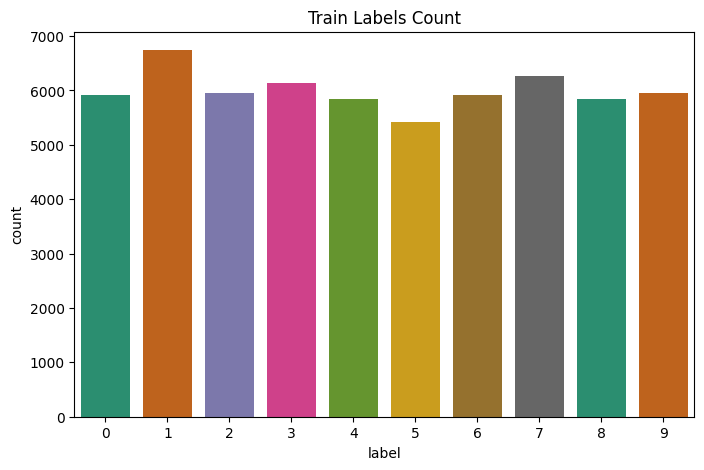

In [74]:
# Plot label counts in training data
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train, palette='Dark2')
plt.title('Train Labels Count')
plt.show()

In [75]:
train['label'].value_counts().sort_index()

,count
label,
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851


/tmp/ipython-input-4023834011.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(row[0])


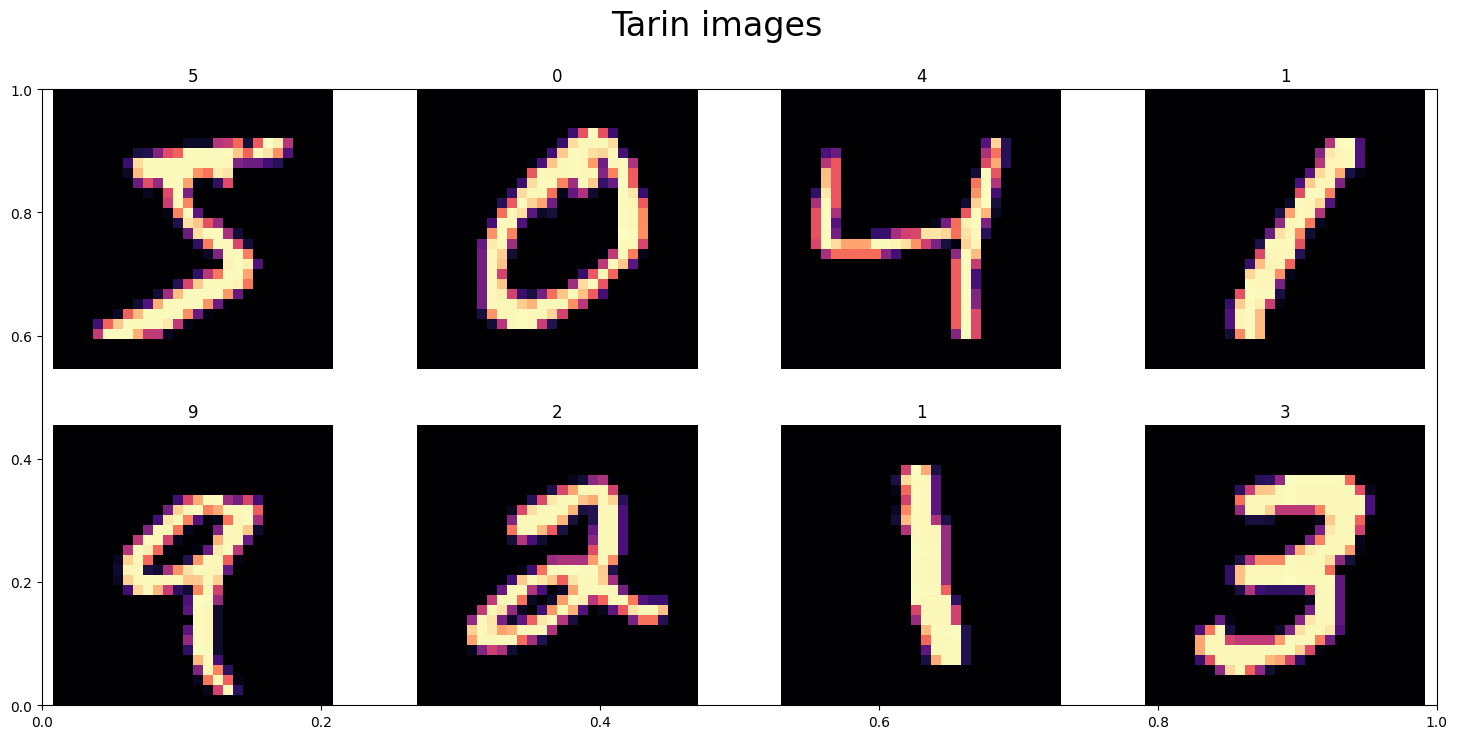

In [76]:
#first few train images with labels:
fig, ax = plt.subplots(figsize=(18,8))
for ind, row in train.iloc[:8, :].iterrows():
  plt.subplot(2,4, ind+1)
  plt.title(row[0])
  img = row.to_numpy()[1:].reshape(28, 28)
  fig.suptitle('Tarin images', fontsize=24)
  plt.axis('off')
  plt.imshow(img, cmap='magma')

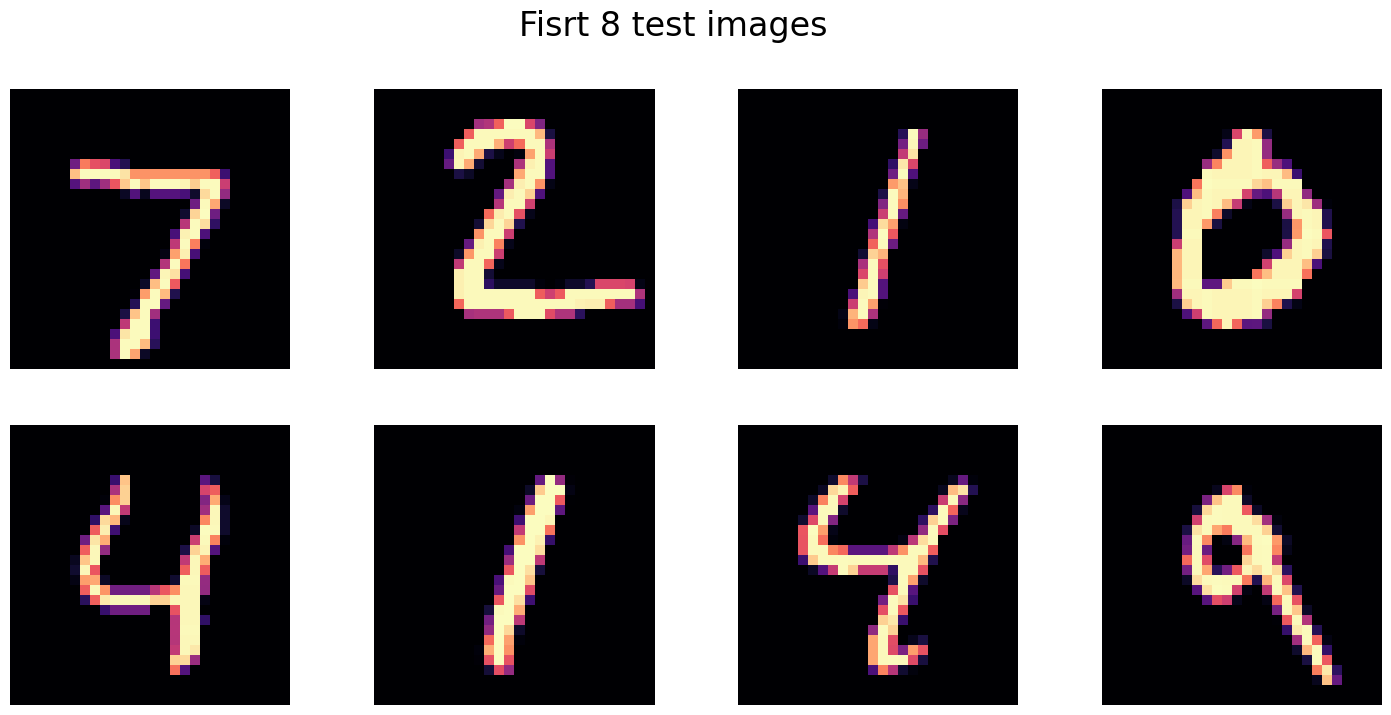

In [77]:
fig, axes = plt.subplots(2,4, figsize=(18,8))
fig.suptitle('Fisrt 8 test images', fontsize=24)

for i, (ind, row) in enumerate(test.iloc[:8, :].iterrows()):
  ax = axes[i // 4, i % 4]
  #If test has a labe; column, exclude it: otherwise use all columns
  img_data = row.to_numpy()[1:] if 'label' in test.columns else row.to_numpy()
  img = img_data.reshape(28, 28)
  ax.imshow(img, cmap='magma')
  ax.axis('off')

plt.show()


In [78]:
 #Preprocessing
 #split into image and labels and convert to numpy array
 x = train.iloc[:, 1:].to_numpy()
 y =train['label'].to_numpy()

 #test dataset
 test = test.loc[:, :].to_numpy()

 for i in [x,y,test]:
  print(i.shape)

(60000, 784)
(60000,)
(10000, 785)


In [79]:
#normalize the data
#==================

x = x /255.0
test = test / 255.0

In [80]:
#separte features and model
x_test = test[:, 1:] #colume 1-784= pixel values
y_test = test[:, 0] #columns 0 = labels


#Normalize
x_test = x_test / 255.0

#Reshape for CNN:
x_test = x_test.reshape(-1,28,28,1)

#Cheaking shapes
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_test: (10000, 28, 28, 1)
y_test: (10000,)


In [81]:
# One hot encode target:
#=======================


#shape and values of target:
print(y.shape)
print(y[0])


#convert Y_train to categroical by one-hot-encoding
y_enc = to_categorical(y,num_classes=10)


#shape and values target
print(y_enc.shape)
print(y_enc[0])

(60000,)
5
(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [82]:
from sklearn.model_selection import train_test_split

# random seed
random_seed = 2

# train validation split
x_train, x_val, y_train_enc, y_val_enc = train_test_split(
    x, y_enc, test_size=0.3, random_state=random_seed
)

# Reshape for CNN (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)

# shape check
for arr in [x_train, y_train_enc, x_val, y_val_enc]:
    print(arr.shape)


(42000, 28, 28, 1)
(42000, 10)
(18000, 28, 28, 1)
(18000, 10)


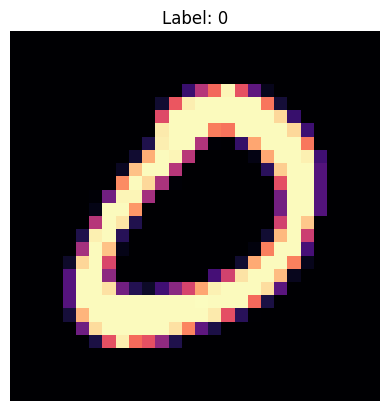

In [83]:
# Find the index of the first image with label 0
index = np.argmax(y_train_enc[:, 0] == 1)  # checks which one-hot vector has 1 at position 0

# Reshape X_train to include the channel dimension
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)

# Display the image
plt.imshow(x_train_reshaped[index][:, :, 0], cmap='magma')
plt.title(f"Label: {y_train_enc[index, :].argmax()}")
plt.axis('off')
plt.show()


[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


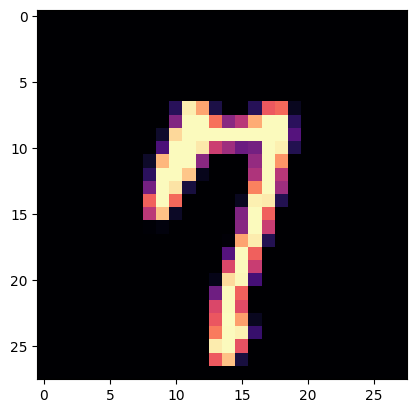

In [84]:
# Reshape X_train to include the channel dimension for plotting
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)

# Display the first image in the reshaped x_train
g = plt.imshow(x_train_reshaped[0][:, :, 0], cmap='magma')
print(y_train_enc[0])


[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


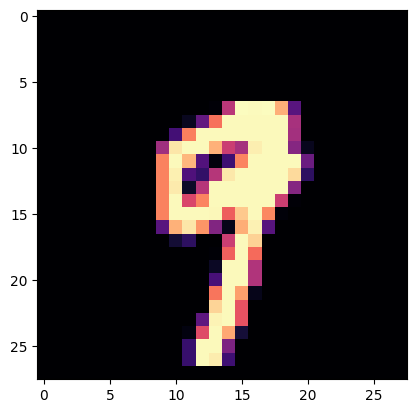

In [85]:
# Reshape X_train to include the channel dimension for plotting
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)

# Display the 10th image in the reshaped x_train
g = plt.imshow(x_train_reshaped[9][:, :, 0], cmap='magma')
print(y_train_enc[9])




In [86]:
INPUT_SHAPE = (28, 28, 1)
OUTPUT_SHAPE = 10
BATCH_SIZE = 128
EPOCHS = 10
VERBOSE = 2

In [87]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPool2D((2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
# Compile the model
model.compile(
    optimizer='adam',                # Adaptive Moment Estimation optimizer
    loss='categorical_crossentropy', # For multi-class classification
    metrics=['accuracy']             # Track accuracy during training
)

# Alternatively, written in one line:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [97]:
print(x_train.shape, y_train_enc.shape)
print(x_val.shape, y_val_enc.shape)

(42000, 28, 28, 1) (42000, 10)
(18000, 28, 28, 1) (18000, 10)


In [90]:
# Reshape X_train and X_val for CNN
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)
x_val_reshaped = x_val.reshape(-1, 28, 28, 1)

history = model.fit(
    x_train_reshaped, y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=VERBOSE,
    validation_data=(x_val_reshaped, y_val_enc)
)

Epoch 1/10
329/329 - 47s - 142ms/step - accuracy: 0.8848 - loss: 0.3742 - val_accuracy: 0.9736 - val_loss: 0.0850
Epoch 2/10
329/329 - 32s - 97ms/step - accuracy: 0.9713 - loss: 0.0993 - val_accuracy: 0.9803 - val_loss: 0.0661
Epoch 3/10
329/329 - 36s - 109ms/step - accuracy: 0.9796 - loss: 0.0708 - val_accuracy: 0.9844 - val_loss: 0.0533
Epoch 4/10
329/329 - 38s - 115ms/step - accuracy: 0.9830 - loss: 0.0571 - val_accuracy: 0.9871 - val_loss: 0.0451
Epoch 5/10
329/329 - 34s - 102ms/step - accuracy: 0.9860 - loss: 0.0464 - val_accuracy: 0.9821 - val_loss: 0.0610
Epoch 6/10
329/329 - 41s - 123ms/step - accuracy: 0.9885 - loss: 0.0381 - val_accuracy: 0.9878 - val_loss: 0.0411
Epoch 7/10
329/329 - 33s - 102ms/step - accuracy: 0.9905 - loss: 0.0319 - val_accuracy: 0.9897 - val_loss: 0.0374
Epoch 8/10
329/329 - 44s - 134ms/step - accuracy: 0.9910 - loss: 0.0277 - val_accuracy: 0.9882 - val_loss: 0.0417
Epoch 9/10
329/329 - 34s - 103ms/step - accuracy: 0.9925 - loss: 0.0249 - val_accuracy: 0

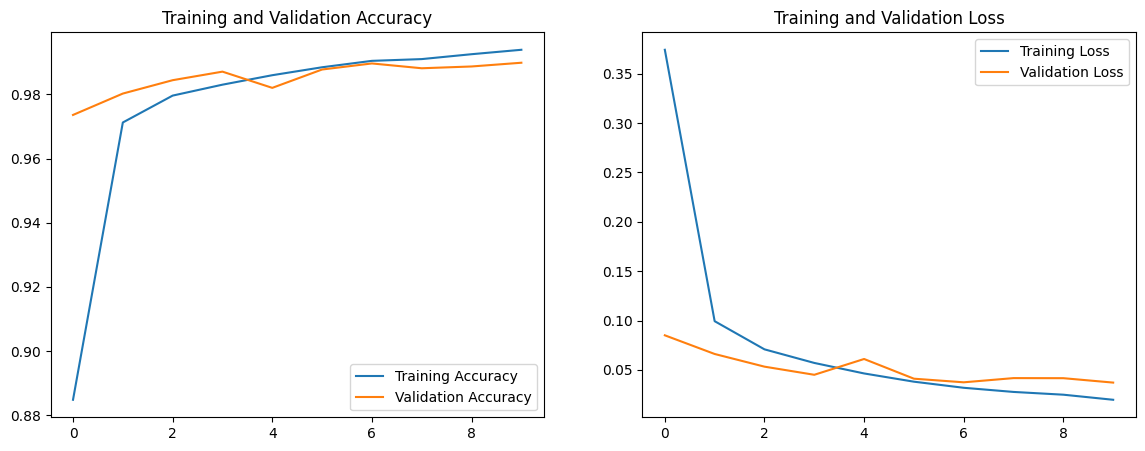

In [91]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()


In [92]:
# model loss and accuracy on validation set
model.evaluate(x_val, y_val_enc, verbose=False)

[0.03715064004063606, 0.9898889064788818]

In [93]:
# predicted values
y_pred_enc = model.predict(x_val)

# actual classes
y_act = [np.argmax(i) for i in y_val_enc]

# decoding predicted values
y_pred = [np.argmax(i) for i in y_pred_enc]

print(y_pred_enc[0])
print(y_pred[0])

563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
[1.7343445e-13 1.5774193e-10 9.9999994e-01 1.8318952e-10 3.5763052e-11
 2.1863953e-13 3.0954145e-13 1.6273306e-10 4.7919160e-12 4.3566127e-15]
2


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1778
           1       0.99      1.00      0.99      2023
           2       0.99      0.99      0.99      1814
           3       1.00      0.99      0.99      1889
           4       0.99      0.98      0.99      1789
           5       0.99      0.99      0.99      1646
           6       0.99      0.99      0.99      1775
           7       0.99      0.99      0.99      1838
           8       0.99      0.98      0.99      1713
           9       0.98      0.99      0.98      1735

    accuracy                           0.99     18000
   macro avg       0.99      0.99      0.99     18000
weighted avg       0.99      0.99      0.99     18000



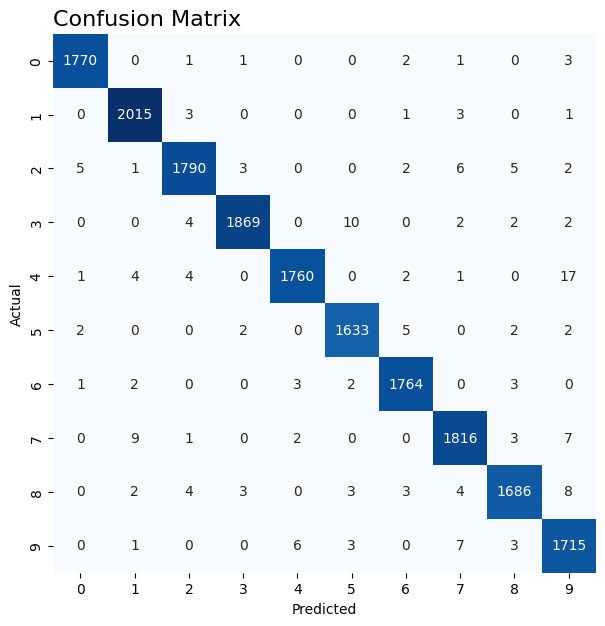

In [94]:
print(classification_report(y_act, y_pred))

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(confusion_matrix(y_act, y_pred), annot=True,
            cbar=False, fmt='1d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix', loc='left', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()


In [95]:
# predicted values
test_reshaped = test[:, 1:].reshape(-1, 28, 28, 1)  # Reshape test data
y_pred_enc = model.predict(test_reshaped)

# decoding predicted values
y_pred = [np.argmax(i) for i in y_pred_enc]

print(y_pred_enc[0])
print(y_pred[0])



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
[9.8338742e-12 4.6452531e-09 9.4986286e-09 1.8757962e-09 1.0445697e-09
 1.1980909e-10 1.2154368e-13 9.9999994e-01 2.9907889e-11 2.2597062e-08]
7


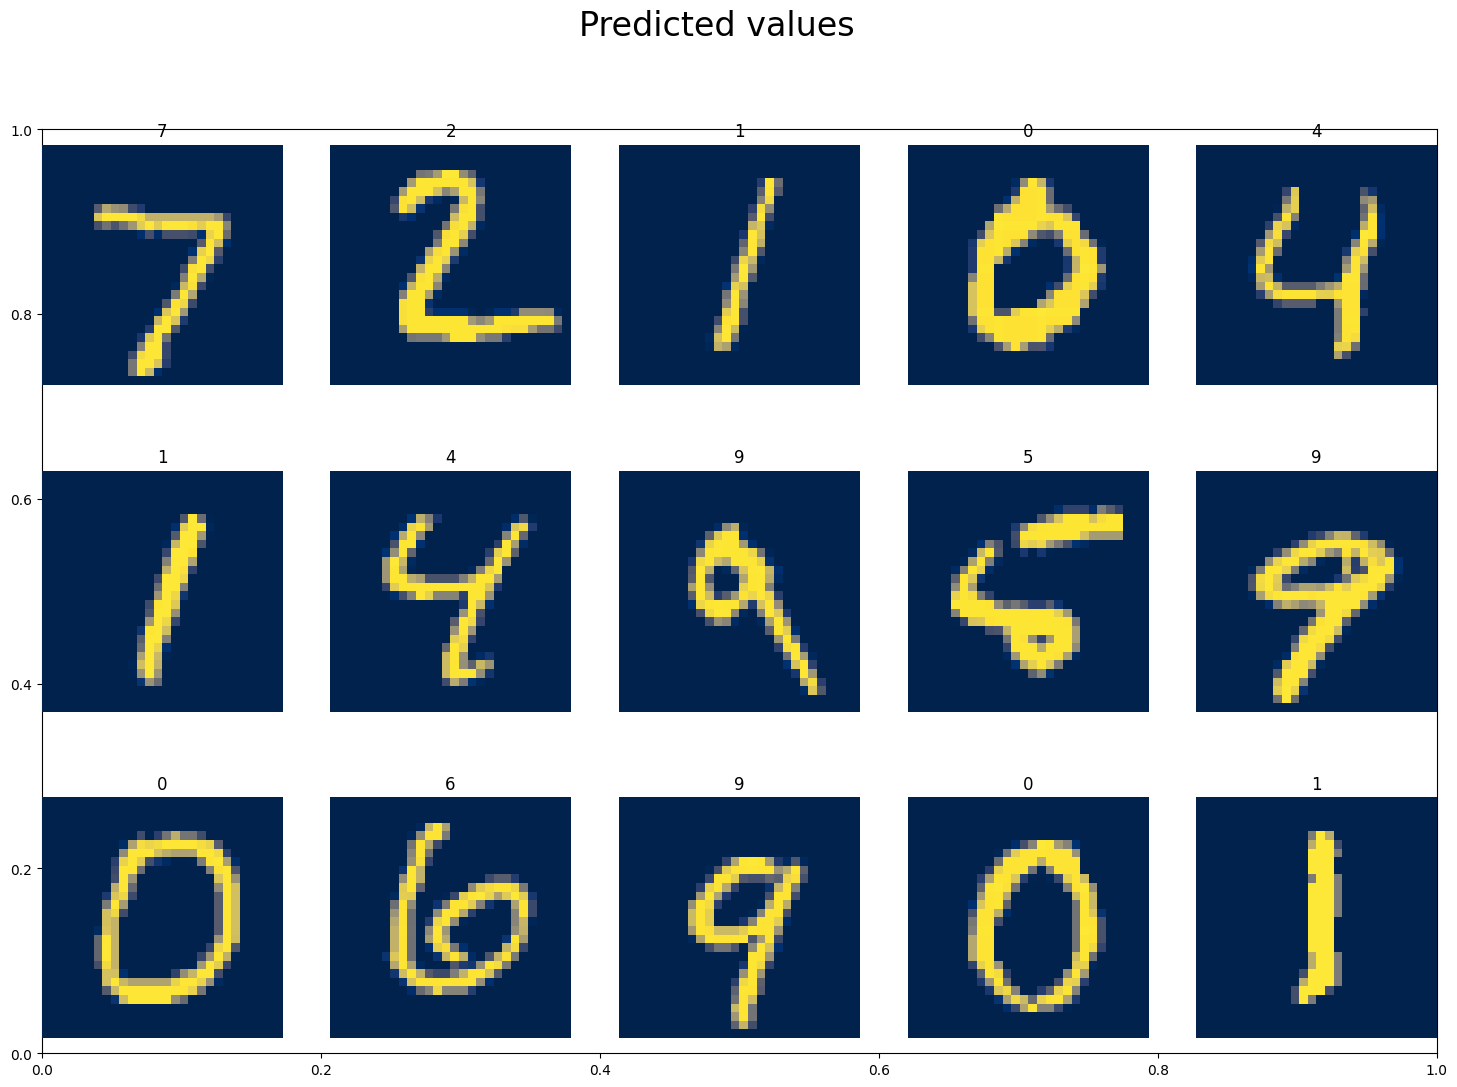

In [96]:
# predicted targets of each image
# (labels above the images are predicted labels)
fig, ax = plt.subplots(figsize=(18, 12))
for ind, row in enumerate(test[:15]):
    plt.subplot(3, 5, ind+1)
    plt.title(y_pred[ind])
    img = row[1:].reshape(28, 28) # Exclude the label column and reshape
    fig.suptitle('Predicted values', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='cividis')


**END**